> **Traçabilité (fusion Codes_finaux) :** notebook présent uniquement dans `Colab_Notebooks/spam_1_DNN_Keras_base_Dropout.ipynb` (pas d'équivalent côté Codes prof), copié tel quel. Variante Colab de `spam_1_DNN_Keras_base` avec ajout de dropout, différente de `spam_2_DNN_Keras_dropout.ipynb` (version prof).

---
# DNN : `spam` (avec `Keras`, avec drop out)
---

## Packages

In [35]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras import layers, models, callbacks
from keras.layers import Dense, Dropout, Activation

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 1. Données
---

### 1.1. Importation

In [37]:


# En local :
# directory = '/Users/vincentlefieux/Dropbox/Docs_ACADEMIQUE/Data/'

# Sur Google collab ou Onyxia (sur un répertoire temporaire) :
# directory = ''

# Sur Google collab (sur le drive) :
from google.colab import drive
drive.mount('/content/drive')
directory = '/content/drive/MyDrive/Colab_Notebooks/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
data = pd.read_csv(directory + 'spam.csv',
                   header    = 0,
                   index_col = None,
                   sep       = ',',
                   decimal   = '.')

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [40]:
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_leftbrac,char_freq_leftsquarebrac,char_freq_exclaim,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### 1.2. Gestion des données manquantes

In [41]:
missing_percentage = data.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
No


### 1.3. Gestion des variables

In [42]:
target = 'spam'

y = data[target]
X = data.drop(target, axis=1)

# ajouter hot encoding si besoin (ici il n'y a pas de X quali)

### 1.4. Création des échantillons de validation et test

In [43]:
# attention, ici pas de validation croisée : 1 ech dapprentissage, 1 ech de validation et 1 ech test
# code à réadapter pour validation croisée
test_portion  = 1/5
valid_portion = 1/5

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion, random_state=1234)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (2944, 57)
Dimensions de X_valid : (736, 57)
Dimensions de X_test  : (921, 57)
Dimensions de y_train : (2944,)
Dimensions de y_valid : (736,)
Dimensions de y_test  : (921,)


### 1.5. Normalisation des covariables

On normalise (centrage-réduction) les covariables :

In [44]:
scaler = StandardScaler(with_mean=True, with_std=True)    # options facultatives car par défaut - centrage et réduction
scaler.fit(X_train)   # on calcule sur l'éch d'apprentissage uniquement, attention ne pas intégrer l'éch test

# on applique la normalisation des 3 échantillons X calibrée sur ech d'apprentissage
X_train_norm = scaler.transform(X_train)
X_valid_norm = scaler.transform(X_valid)
X_test_norm  = scaler.transform(X_test)

---
## 2. DNN
---

### 2.1. Architecture

In [45]:
# Paramétrage de la structure du réseau AVEC DROP OUT

dim_inputs  = (X_train_norm.shape[1],)    # nombre de covariables X
dim_outputs = 1   # nb de Y

n_units_hl1 = 50  # nb de neurones pour couche 1
n_units_hl2 = 30  # nb de neurones pour couche 2

dropout_hl1 = 0.3   # taux de drop out sur couche 1
dropout_hl2 = 0.3   # taux de drop out sur couche 2
model = models.Sequential(name='DNN')   # création du modèle comme réseau de neurones DNN = Le modèle séquentiel est une pile linéaire de couches.

model.add(layers.Input(shape=dim_inputs, name='Inputs'))    # définition du nombre de X en entrée

# layers/Dense : on spécifie donc qu'on est sur un DNN - réseau dense
model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_layer_1'))  # définition des paramètres couche 1 : fonction d'activation relu

model.add(layers.Dropout(dropout_hl2)) # drop out sur couche 1

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))  # définition des paramètres couche 2 : fonction d'activation relu


model.add(layers.Dropout(dropout_hl2))  # drop out sur couche 2

model.add(layers.Dense(units=dim_outputs, activation='sigmoid', name='Output_layer')) # définition des paramètres couche sortie : fonction d'activation sigmoid

model.summary()   # récap info structure DNN

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_layer_1 (Dense)          │ (None, 50)             │         2,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_2 (Dense)          │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,461 (17.43 KB)

 Trainable params: 4,461 (17.43 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

In [46]:
# configuration du processus d'apprentissage
model.compile(optimizer = 'adam',                   # type d'optimiseur appelé adam: mise à jour des poids pour diminuer l'erreur (descente de gradient pour retro propagation)
              loss      = 'binary_crossentropy',    # optimisation : fonction de coût à minimiser pour calculer les paramètres, ici  pour classif binaire entropie de Shannon
              metrics   = ['accuracy'])             # ajout d'autres critères d'erreur pour info - critère de performance, ici accuracy car classification supervisée - voir pour ajoutr d'autres critères si besoin

### 2.3. Entraînement

In [30]:
# entraînement du modèle sur éch d'apprentissage par mini lots de 500, sur 200 époques
# validation sur ech de validation
hist = model.fit(X_train_norm,          # attention sur X normalisés
                 y_train,
                 batch_size      = 500,                         # nb de mini lots
                 epochs          = 200,                         # nb d'époques
                 validation_data = (X_valid_norm, y_valid),     # validation sur ech de validation
                 verbose         = 1)                           # barre de progression + commentaires

# commentaire sur la sortie :
# 6/6 car comme il y a des mini lots de 500 et qu'il y a 2900 lignes, il y a 6 itérations
# - accuracy: 0.9973 - loss: 0.0091 => calcul sur ech d'apprentissage
# - val_accuracy: 0.9253 - val_loss: 0.6665 => calcul sur ech de validation

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5530 - loss: 0.7297 - val_accuracy: 0.6861 - val_loss: 0.6487
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6583 - loss: 0.6495 - val_accuracy: 0.7690 - val_loss: 0.5954
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7181 - loss: 0.5958 - val_accuracy: 0.8057 - val_loss: 0.5520
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7571 - loss: 0.5475 - val_accuracy: 0.8288 - val_loss: 0.5121
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7972 - loss: 0.5067 - val_accuracy: 0.8410 - val_loss: 0.4735
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8234 - loss: 0.4577 - val_accuracy: 0.8505 - val_loss: 0.4384
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8305 - loss: 0.4434 - val_accuracy: 0.8573 - val_loss: 0.4067
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8471 - loss: 0.4033 - val_accuracy: 0.8736 - val_loss:

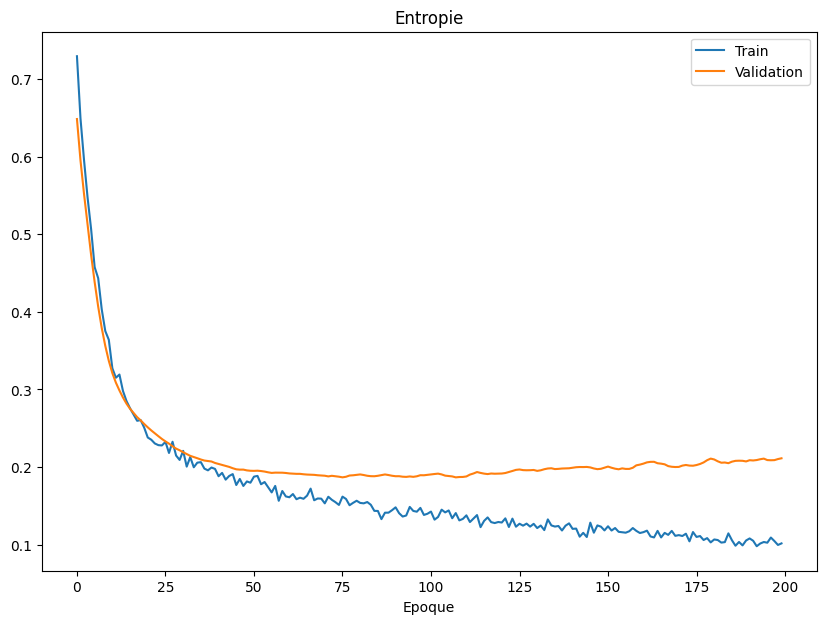

In [31]:
# Graphe de l'évolution de l'entropie sur ech d'apprentissage et ech de validation, en fonction de l'époque
# optionnel, pour visualiser, mais pas besoin pour choisir le nb dépoques => cf early stopping
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(hist.history['loss'], label='Train')
ax.plot(hist.history['val_loss'], label='Validation')
ax.set_xlabel('Epoque')
ax.set_title('Entropie')
ax.legend(loc='best')
plt.show()

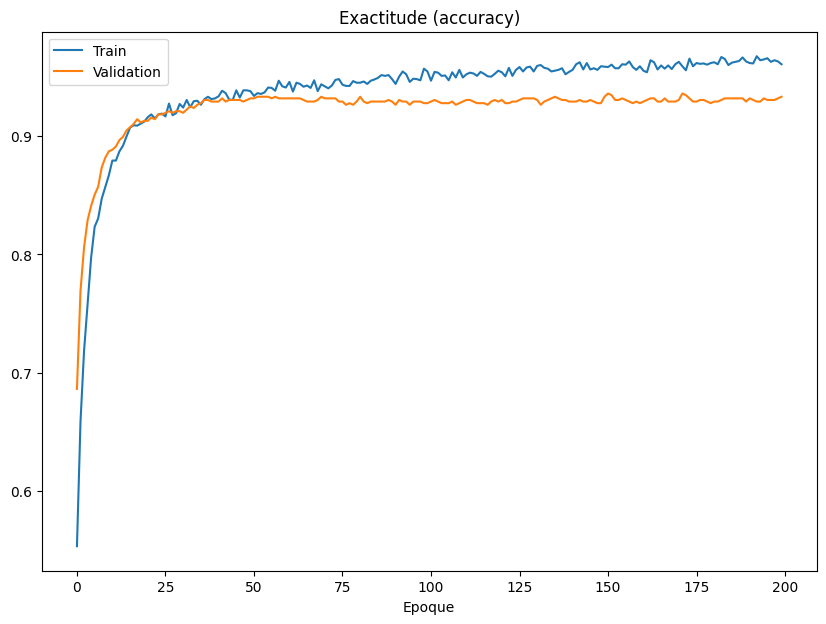

In [32]:
# graphe de l'accuracy sur ech app et validation en fonction des époques
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(hist.history['accuracy'], label='Train')
ax.plot(hist.history['val_accuracy'], label='Validation')
ax.set_xlabel('Epoque')
ax.set_title('Exactitude (accuracy)')
ax.legend(loc='best')
plt.show()

### Avec early stopping

In [49]:
# EARLY STOPPING
# ajouter les commentaires

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",         # surveille l'entropie sur l'echantillon de validation - possible d'utiliser autre critère métier si important (ex : accuracy)
    mode="min",                 # on cherche à minimiser le critère (monitor)
    patience=10,                # à diminuer si on est sur des images
    restore_best_weights=True,  # restore les poids de l'époque sléectionnée
)

In [50]:
hist = model.fit(X_train_norm,          # attention sur X normalisés
                 y_train,
                 batch_size      = 500,                         # nb de mini lots
                 epochs          = 200,                         # nb d'époques
                 validation_data = (X_valid_norm, y_valid),     # validation sur ech de validation
                 callbacks=[early_stop],                        # early stopping callback
                 verbose         = 1)                           # barre de progression + commentaires

# pas d'affichage de l'entropie à l'étape 0 (initialisation), commence à partir de l'étape 1

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9372 - loss: 0.1805 - val_accuracy: 0.9389 - val_loss: 0.1912
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9321 - loss: 0.1787 - val_accuracy: 0.9361 - val_loss: 0.1917
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9331 - loss: 0.1752 - val_accuracy: 0.9375 - val_loss: 0.1918
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9358 - loss: 0.1763 - val_accuracy: 0.9375 - val_loss: 0.1918
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9365 - loss: 0.1757 - val_accuracy: 0.9375 - val_loss: 0.1921
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9361 - loss: 0.1798 - val_accuracy: 0.9389 - val_loss: 0.1920
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9409 - loss: 0.1637 - val_accuracy: 0.9389 - val_loss: 0.1921
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9395 - loss: 0.1633 - val_accuracy: 0.9402 - val_loss:

### 2.4. Optimisation du DNN

In [ ]:
# pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.2 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

Création d'une fonction = hypermodèle dans lequel on définit les hyperparamètres pour les faire varier automatiquement

Hyperparamètres:
- nb de couches
- nb de neurones


In [ ]:
def model_builder(hp):
  model = models.Sequential()
  model.add(layers.Input(shape=dim_inputs, name='Inputs'))    # définition du nombre de X en entrée

  # nb de couches
  for i in range(hp.Int('num_layers', 2, 4)):
    model.add(layers.Dense(
        units=hp.Int(f"units_{i}", min_value=32, max_value=256, step=32),
            activation="relu"
model.add(layers.Dropout(dropout_hl2)) # drop out sur couche 1

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))  # définition des paramètres couche 2 : fonction d'activation relu


model.add(layers.Dropout(dropout_hl2))  # drop out sur couche 2

model.add(layers.Dense(units=dim_outputs, activation='sigmoid', name='Output_layer')) # définition des paramètres couche sortie : fonction d'activation sigmoid

model.summary()   # récap info structure DNN

### 2.5. Prévisions

In [69]:
# Application du modèle sur l'éch test - génération des y predites = proba prédites
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[9.9999893e-01],
       [3.3009676e-03],
       [6.2621186e-11],
       [2.1012642e-03],
       [1.2671244e-06]], dtype=float32)

In [70]:
# erreur de classification (s = 0.5) à partir des probas prédites
y_test_pred_classes = (y_test_pred > 0.5).astype(int)
y_test_pred_classes[0:5]

array([[1],
       [0],
       [0],
       [0],
       [0]])

In [71]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.1683
Exactitude test : 0.9511
